### Setting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re

from pathlib import Path
BASE_DIR = Path().resolve().parent   
DATA_DIR = "G:/我的云端硬盘/NLP_project"
model_dir = "G:/我的云端硬盘/NLP_project/edu_models"

# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/NLP_project")
# model_dir = Path("/content/drive/MyDrive/NLP_project/edu_models")

def show_full(df):
    """
    Fully display a DataFrame without any truncation.
    Works for any df[...] slice.
    """
    import pandas as pd
    from IPython.display import display

    with pd.option_context(
        "display.max_colwidth", None,
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None
    ):
        display(df)

In [2]:
import torch
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} as device.")

Using cpu as device.


### Load data

In [20]:
df_subchunks = pd.read_parquet(f"{DATA_DIR}/df_subchunks_raw.parquet")  

In [8]:
Industry_chunks = (
    df_subchunks.loc[df_subchunks["industry"] == "Education & Research",
                     ["chunk_uid", "url", "date", "title", "topic", "chunk_text"]]
    .copy()
    .rename(columns={"topic": "topic_v0"})
)
print(len(Industry_chunks))
Industry_chunks.head(2)

10130


,chunk_uid,url,date,title,topic_v0,chunk_text
143,88_0_0_0_0,https://www.edexlive.com/news/2024/Oct/23/in-a...,2024-10-23,"""In a future where AI is more prevalent, teach...",1,"""In a future where AI is more prevalent, teach..."
249,166_0_0_0_0,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",30,"""Switching To Data Science Career"": ""Guide On ..."


### Bertopic

In [10]:
# ! pip install bertopic

In [12]:
### customize bertopic model
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

RANDOM_STATE = 27

embedding_model = SentenceTransformer("thenlper/gte-small")  # , device="cuda"

umap_model = UMAP(
    n_neighbors=50, # smaller n_neighbors will -> local structure -> more detailed topics
    n_components=15, # smaller n_components will -> more coarse topics
    min_dist=0.1, # smaller min_dist will -> more clustered紧凑 topics
    metric="cosine",
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=200, # smaller min_cluster_size will -> more detailed topics
    min_samples=100, # smaller min_samples -> easier get into topics -> more detailed topics, but also more noise
    metric="euclidean",
    cluster_selection_method="eom"
)

vectorizer_model = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,                 # 关键：别太高，保住 gpt/openai/llm
    max_df=0.70,              # 砍掉跨站模板词，但不至于太猛
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]{2,}\b",
    # 你如果想加自定义 stopwords，见下方“可选增强”
)
ctfidf_model = ClassTfidfTransformer()

# All steps together
topic_model = BERTopic(
  embedding_model=embedding_model,          # Step 1 - Extract embeddings
  umap_model=umap_model,                    # Step 2 - Reduce dimensionality
  hdbscan_model=hdbscan_model,              # Step 3 - Cluster reduced embeddings
  vectorizer_model=vectorizer_model,        # Step 4 - Tokenize topics
  ctfidf_model=ctfidf_model,                # Step 5 - Extract topic words
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
docs = Industry_chunks["chunk_text"].tolist()
topics, probs = topic_model.fit_transform(docs)

In [14]:
Industry_topics = topic_model.get_topic_info()
Industry_chunks_topics = Industry_chunks.assign( topic=topics,  probability=probs)

In [17]:
show_full(Industry_topics[["Topic", 'Representation',"Count"]])

,Topic,Representation,Count
0,-1,"[amkam, amkam amkam, dej, fde, amkamp, gmk, amkam fde, cde, tau, gmkam]",34
1,0,"[teachers, educators, writing, teaching, classroom, teacher, cheating, assignments, essays, essay]",6804
2,1,"[scientist, data scientist, engineer, cloud, filled, certificate, specialization, coursera, sql, shoes]",2033
3,2,"[mars, sciencedaily, stars, chemical, universe, hours ago, galaxies, galaxy, telescope, crystal]",880
4,3,"[suicide, google scholar, attributions, sitemap terms, articles week, new articles, ris, compile, print email, summaries]",379


In [20]:
Industry_topics.to_csv(f"{DATA_DIR}/EDU_specific/Industry_topics.csv", index=False)
Industry_chunks_topics.to_parquet(f"{DATA_DIR}/EDU_specific/Industry_chunks_topics.parquet", index=False)

In [21]:
Industry_chunks_topics = pd.read_parquet(f"{DATA_DIR}/EDU_specific/Industry_chunks_topics.parquet")

### Filter AI Impact related content

In [22]:
manual_related_topics = [0,1,2,3]
df_ai_impact = Industry_chunks_topics.loc[Industry_chunks_topics["topic"].isin(manual_related_topics)].copy()
print(len(df_ai_impact))

10096


In [23]:
df_ai_impact.to_parquet(f"{DATA_DIR}/EDU_specific/edu_df_ai_impact.parquet", index=False)

### Sentiment Analysis on chunk level

In [4]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/EDU_specific/edu_df_ai_impact.parquet")

##### 1. use LLM to generate labels

In [5]:
df_ai_impact['topic'].value_counts()    

topic
0    6804
1    2033
2     880
3     379
Name: count, dtype: int64

In [10]:
def topic_sample_n(topic_size):
    if topic_size >= 5000:
        return 250
    elif topic_size >= 1000:
        return 150
    elif topic_size >= 500:
        return 80
    else:
        return 50

random_state = 38

df_ai_impact_sample = (
    df_ai_impact
    .groupby("topic", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), topic_sample_n(len(x))),
        random_state=random_state
    ))
    .reset_index(drop=True)
)

df_ai_impact_sample = df_ai_impact_sample[["chunk_uid", "topic", "chunk_text"]]
print(len(df_ai_impact_sample))
df_ai_impact_sample["topic"].value_counts()

530


C:\Users\ss363\AppData\Local\Temp\ipykernel_35364\2104407867.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


topic
0    250
1    150
2     80
3     50
Name: count, dtype: int64

In [11]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [12]:
system_msg = """
You are an expert analyst of the Education and Research industry.

Your task is to evaluate how educational institutions and research organizations
described in the text are expected to be impacted by AI or AI-related developments.

Education and Research institutions include, but are not limited to:
- universities and colleges
- K–12 schools and school systems
- online education platforms
- research institutes and laboratories
- academic publishers and scholarly organizations
- educational technology providers
- academic communities and researchers
- students and educators

You must classify the impact into EXACTLY ONE of the following:

1. "positively"
   The text suggests that AI or related technologies are expected to benefit
   the education or research ecosystem.

   This may include:
   - improved teaching tools or personalized learning
   - AI tutoring or educational assistants
   - faster research workflows or literature review
   - improved data analysis for scientific discovery
   - productivity gains for researchers or educators
   - expanded access to education
   - improved academic collaboration or knowledge discovery

2. "negatively"
   The text suggests that AI or related technologies are expected to harm,
   disrupt, or create risks for the education or research ecosystem.

   This may include:
   - academic cheating or plagiarism using AI
   - unreliable AI-generated research content
   - hallucinated citations or fabricated references
   - threats to academic integrity
   - misuse of AI in assignments or exams
   - decline in critical thinking or learning outcomes
   - job displacement for educators or academic staff
   - ethical concerns in research or data use

3. "hard-to-say"
   The text is neutral, mixed, uncertain, speculative, descriptive without
   clear directional impact, or presents both benefits and risks without a
   clear dominant direction.

### Decision Rules

- Focus on the MAIN directional implication of the text.
- Do not over-interpret minor phrases.
- If the text discusses both pros and cons without a clear dominant direction,
  choose "hard-to-say".
- If the text is mostly descriptive or factual without clear directional
  judgment, choose "hard-to-say".
- Ignore boilerplate, navigation fragments, or irrelevant web residue.
- Base your decision only on substantive content.

### Output Requirements

Return valid JSON with exactly two fields:

{
  "impact_label": "...",
  "reasoning": "..."
}

Where:
- "impact_label" must be one of: "positively", "negatively", "hard-to-say"
- "reasoning" should briefly summarize why the impact is classified that way.
"""

impact_user_template = """
Here is a text segment discussing the education or research sector:

{chunk_text}

Please determine whether the described institutions, organizations,
or communities are expected to be impacted positively, negatively,
or in an unclear/mixed way by AI or AI-related developments.

Return JSON only.
"""

impact_schema = {
    "type": "object",
    "properties": {
        "impact_label": {
            "type": "string",
            "enum": ["positively", "negatively", "hard-to-say"]
        },
        "reasoning": {
            "type": "string"
        }
    },
    "required": ["impact_label", "reasoning"],
    "additionalProperties": False
}

In [13]:
@retry(
    retry=retry_if_exception_type((
        openai.RateLimitError,
        openai.APIConnectionError,
        openai.APITimeoutError,
        openai.InternalServerError
    )),
    wait=wait_exponential(multiplier=1, min=2, max=20),
    stop=stop_after_attempt(4),
    reraise=True
)
def get_answer(client, system_msg, user_msg, model="deepseek-chat"):
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )
    content = completion.choices[0].message.content
    return json.loads(content)

VALID_LABELS = {"positively", "negatively", "hard-to-say"}

def normalize_impact_result(result):
    fallback = {
        "impact_label": "hard-to-say",
        "reasoning": "Unclear or insufficient directional evidence."
    }

    if not isinstance(result, dict):
        return fallback

    label = result.get("impact_label")
    reasoning = result.get("reasoning", "")

    if label not in VALID_LABELS:
        return fallback

    if not isinstance(reasoning, str) or not reasoning.strip():
        reasoning = fallback["reasoning"]

    normalized = {
        "impact_label": label,
        "reasoning": reasoning.strip()
    }

    try:
        validate(instance=normalized, schema=impact_schema)
        return normalized
    except ValidationError:
        return fallback

In [14]:
train_ai_impact_label = []

for idx, row in df_ai_impact_sample.iterrows():

    text = row["chunk_text"]

    user_msg = impact_user_template.format(
        chunk_text=text[:12000]
    )

    try:
        raw_result = get_answer(
            client=client,
            system_msg=system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )
        result = normalize_impact_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "impact_label": None,
            "reasoning": None,
            "api_status": f"failed: {err_msg}"
        }

        print(f"[Row {idx}] Failed: {e}")

    result["chunk_text"] = text
    result["topic"] = row["topic"]
    result['chunk_uid'] = row['chunk_uid']

    train_ai_impact_label.append(result)

In [15]:
df_train_ai_impact_label = pd.DataFrame(train_ai_impact_label)
display(df_train_ai_impact_label['impact_label'].value_counts())
imbalanced_df = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively'][['chunk_uid','chunk_text', 'reasoning']]
imbalanced_labels = df_train_ai_impact_label[df_train_ai_impact_label['impact_label'] == 'negatively']['chunk_uid'].to_list()
print(imbalanced_labels)
# show_full(imbalanced_df[['chunk_uid','reasoning']])

impact_label
positively     248
hard-to-say    221
negatively      61
Name: count, dtype: int64

['120754_0_0_0_0', '2755_0_0_0_0', '128080_2_0_0_1', '27756_1_0_0_2', '143167_1_0_1_1', '120949_0_0_0_1', '144926_0_0_0_0', '88588_0_0_0_1', '104239_1_1_0_0', '47635_0_0_0_0', '104234_0_0_0_0', '30308_0_0_0_0', '127257_0_1_0_0', '30804_0_1_0_0', '43088_0_0_0_0', '65539_0_0_0_1', '5124_0_0_0_2', '97386_0_0_0_1', '128802_0_0_0_0', '35425_0_0_0_0', '144927_0_0_0_2', '67815_0_0_0_0', '17984_0_0_0_0', '30050_0_0_0_0', '129093_0_0_3_1', '27927_1_0_2_0', '66144_2_0_0_0', '97386_0_0_0_0', '884_0_0_0_0', '115074_0_0_0_2', '43093_1_0_0_1', '136470_0_1_0_1', '32019_0_0_0_0', '32015_1_1_0_1', '62355_0_0_0_2', '73598_1_0_0_2', '148836_0_0_0_0', '102356_2_0_0_2', '137880_0_0_0_1', '45309_0_0_0_0', '1178_0_0_0_1', '11040_0_0_0_3', '115098_0_0_0_0', '32044_0_1_0_1', '69727_0_0_1_2', '43516_0_0_0_2', '123492_0_0_0_0', '33233_1_0_0_2', '30236_0_0_0_0', '146890_0_1_0_0', '32094_3_0_0_1', '41324_1_0_0_0', '140681_0_0_0_0', '104251_0_0_0_2', '30524_0_0_0_0', '75784_0_0_0_2', '127043_0_0_0_2', '32341_3_0_0_

lack negatively labeled samples, use llm api to generate some

In [16]:
df_train_ai_impact_label.to_parquet(f"{DATA_DIR}/EDU_specific/edu_df_ai_impact.parquet", index=False)

##### 2. finetune classifer

In [3]:
df_train_ai_impact_label = pd.read_parquet(f"{DATA_DIR}/EDU_specific/edu_df_ai_impact.parquet")
display(df_train_ai_impact_label['impact_label'].value_counts())

,count
impact_label,
positively,248
hard-to-say,221
negatively,61


In [4]:
label2id = {
    "negatively": 0,
    "hard-to-say": 1,
    "positively": 2
}

id2label = {v: k for k, v in label2id.items()}

df_train = (
    df_train_ai_impact_label.loc[df_train_ai_impact_label["impact_label"].isin(label2id.keys()), ["chunk_text", "impact_label"]]
    .rename(columns={"chunk_text": "text"})
    .copy()
)

df_train["label"] = df_train["impact_label"].map(label2id)
df_train = df_train[["text", "label"]].reset_index(drop=True)

df_train.head()

,text,label
0,“These kids are still on their academic path. ...,2
1,"think about, you know, a family member or a ca...",2
2,"""I didn't want to memorise word lists or entir...",1
3,"""I like that we can build stuff, and do stuff ...",2
4,Student Uses ChatGPT to Cheat in Ethics Course...,0


In [10]:
from sklearn.model_selection import train_test_split
train_df, valid_df = train_test_split( df_train, test_size=0.17, random_state=40, stratify=df_train["label"])
print(train_df["label"].value_counts())
print(valid_df["label"].value_counts())

from datasets import Dataset, DatasetDict
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True), preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df.reset_index(drop=True), preserve_index=False)

dataset_dict = DatasetDict({ "train": train_dataset, "validation": valid_dataset})
dataset_dict

label
2    205
1    183
0     51
Name: count, dtype: int64
label
2    43
1    38
0    10
Name: count, dtype: int64


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 439
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 91
    })
})

In [11]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

max_len = 512
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=max_len,
        padding=False,
    )

tokenized_datasets = dataset_dict.map(tokenize_fn, batched=True)
tokenized_datasets

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/439 [00:00<?, ? examples/s]

Map:   0%|          | 0/91 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 439
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 91
    })
})

In [13]:
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "macro_precision": precision,
        "macro_recall": recall
    }

trained_model_name = "edu_ai_impact_classifier"

training_args = TrainingArguments(
    output_dir=f"{model_dir}/{trained_model_name}_ckpt",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=2e-5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [14]:
trainer.train()
trainer.save_model(f"{model_dir}/{trained_model_name}")
tokenizer.save_pretrained(f"{model_dir}/{trained_model_name}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,No log,0.905048,0.626374,0.426033,0.442455,0.459200
2,0.914434,0.793977,0.670330,0.468336,0.448810,0.497348
3,0.914434,0.697726,0.703297,0.581830,0.611957,0.574827
4,0.651580,0.707392,0.692308,0.536797,0.810292,0.536393
5,0.651580,0.635699,0.736264,0.613104,0.713239,0.599102
6,0.427924,0.626472,0.714286,0.502419,0.474806,0.533456
7,0.427924,0.597571,0.747253,0.716330,0.706209,0.731701
8,0.266347,0.615594,0.747253,0.657387,0.746986,0.633456


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/NLP_project/edu_models/edu_ai_impact_classifier/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_project/edu_models/edu_ai_impact_classifier/tokenizer.json')

              precision    recall  f1-score   support

  negatively       0.58      0.70      0.64        10
 hard-to-say       0.74      0.66      0.69        38
  positively       0.80      0.84      0.82        43

    accuracy                           0.75        91
   macro avg       0.71      0.73      0.72        91
weighted avg       0.75      0.75      0.75        91



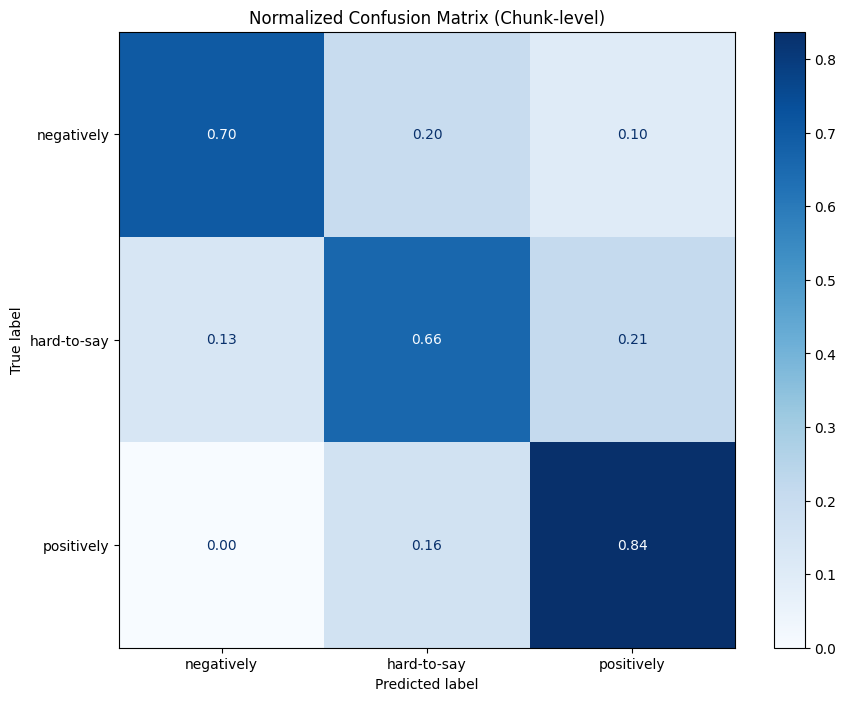

In [15]:
from sklearn.metrics import classification_report
val_pred = trainer.predict(tokenized_datasets["validation"])
val_preds = np.argmax(val_pred.predictions, axis=-1)
val_labels = np.array(tokenized_datasets["validation"]["label"])

print(classification_report(
    val_labels,
    val_preds,
    target_names=[id2label[i] for i in sorted(id2label.keys())],
    zero_division=0
))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_preds, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[id2label[i] for i in sorted(id2label.keys())])
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Normalized Confusion Matrix (Chunk-level)")
plt.show()

##### 3. predict sentiment labels for all df_ai_impact chunks with the fine tuned model

In [24]:
df_ai_impact = pd.read_parquet(f"{DATA_DIR}/EDU_specific/edu_df_ai_impact.parquet")
df_ai_impact.head()

,chunk_uid,url,date,title,topic_v0,chunk_text,topic,probability
0,88_0_0_0_0,https://www.edexlive.com/news/2024/Oct/23/in-a...,2024-10-23,"""In a future where AI is more prevalent, teach...",1,"""In a future where AI is more prevalent, teach...",0,1.0
1,166_0_0_0_0,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",30,"""Switching To Data Science Career"": ""Guide On ...",1,1.0
2,166_0_0_0_1,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",30,"However, you may need to learn additional skil...",1,1.0
3,166_0_0_0_2,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",30,Network with Data Scientists\nNetworking with ...,1,1.0
4,217_0_0_0_0,https://www.prnewswire.co.uk/news-releases/vul...,2024-03-21,"""Vulpy,"" the AI Tutor from Evulpo, Helps Maste...",1,"""Vulpy,"" the AI Tutor from Evulpo, Helps Maste...",0,1.0


In [25]:
print(df_ai_impact.shape)

(10096, 8)


In [26]:
from datasets import Dataset

df_ai_impact_pred = (
    df_ai_impact[['chunk_uid','url','date','title',"topic", "chunk_text"]]
    .rename(columns={"chunk_text": "text"})
    .reset_index(drop=True)
    .copy()
)

pred_dataset = Dataset.from_pandas(df_ai_impact_pred, preserve_index=False)
pred_dataset = pred_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/10096 [00:00<?, ? examples/s]

In [27]:
pred_output = trainer.predict(pred_dataset)
logits = pred_output.predictions

pred_ids = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

# df_ai_impact_pred["pred_label_id"] = pred_ids
df_ai_impact_pred["pred_label"] = [id2label[i] for i in pred_ids]
df_ai_impact_pred["max_prob"] = probs.max(axis=1)

for i, label_name in id2label.items():
    df_ai_impact_pred[f"prob_{label_name}"] = probs[:, i]

print(df_ai_impact_pred.shape)
df_ai_impact_pred.head()

(10096, 11)


,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,88_0_0_0_0,https://www.edexlive.com/news/2024/Oct/23/in-a...,2024-10-23,"""In a future where AI is more prevalent, teach...",0,"""In a future where AI is more prevalent, teach...",positively,0.926871,0.019520,0.053609,0.926871
1,166_0_0_0_0,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",1,"""Switching To Data Science Career"": ""Guide On ...",hard-to-say,0.929538,0.025211,0.929538,0.045251
2,166_0_0_0_1,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",1,"However, you may need to learn additional skil...",hard-to-say,0.885201,0.019310,0.885201,0.095489
3,166_0_0_0_2,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",1,Network with Data Scientists\nNetworking with ...,hard-to-say,0.924415,0.021382,0.924415,0.054203
4,217_0_0_0_0,https://www.prnewswire.co.uk/news-releases/vul...,2024-03-21,"""Vulpy,"" the AI Tutor from Evulpo, Helps Maste...",0,"""Vulpy,"" the AI Tutor from Evulpo, Helps Maste...",positively,0.938869,0.026530,0.034601,0.938869


/tmp/ipykernel_26033/602985794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


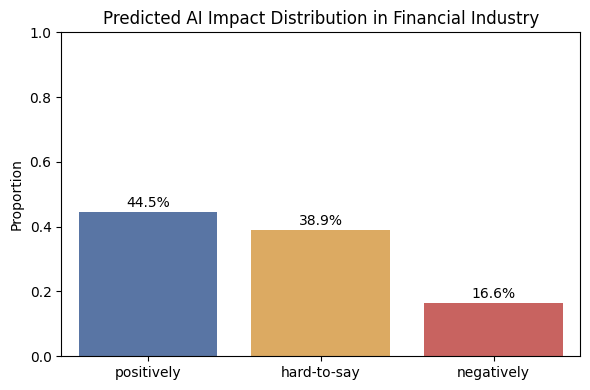

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positively", "hard-to-say", "negatively"]
dist = df_ai_impact_pred["pred_label"].value_counts(normalize=True).reindex(order)

plt.figure(figsize=(6, 4))

sns.barplot(
    x=dist.index,
    y=dist.values,
    palette=["#4C72B0", "#F0AD4E", "#D9534F"]
)

plt.ylabel("Proportion")
plt.xlabel("")
plt.title("Predicted AI Impact Distribution in Financial Industry")
plt.ylim(0, 1)

for i, v in enumerate(dist.values):
    plt.text(i, v + 0.015, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### NER: Company and Technologies

In [3]:
df_ai_impact_pred = pd.read_parquet(f"{model_dir}/edu_senti_predictions.parquet")
df_ai_impact_pred.head(2)

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively
0,88_0_0_0_0,https://www.edexlive.com/news/2024/Oct/23/in-a...,2024-10-23,"""In a future where AI is more prevalent, teach...",0,"""In a future where AI is more prevalent, teach...",positively,0.926871,0.019520,0.053609,0.926871
1,166_0_0_0_0,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",1,"""Switching To Data Science Career"": ""Guide On ...",hard-to-say,0.929538,0.025211,0.929538,0.045251


In [4]:
df_ai_impact_pred['topic'].value_counts()

topic
0    6804
1    2033
2     880
3     379
Name: count, dtype: int64

#### Positive impact

In [5]:
df_ai_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'positively'].sample(500, random_state=38).reset_index(drop=True)

In [9]:
import os
import json
import pandas as pd
from jsonschema import validate, ValidationError

import openai
from openai import OpenAI
from tenacity import (
    retry,
    wait_exponential,
    stop_after_attempt,
    retry_if_exception_type
)

DS_API_KEY = "sk-a0a8781acaa74c52acd7e22c4249185c"
client = OpenAI(
    api_key=DS_API_KEY,
    base_url="https://api.deepseek.com",
)

In [6]:
entity_system_msg = """\
You are an information extraction system for education and research-related news articles.

The user will provide a text block from a news article related to education,
academia, or scientific research.

Your task is to extract only the following:

1. organizations or institutions in the education and research ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS

Extract named organizations or institutions explicitly stated in the text.

These may include:

- universities and colleges
- K–12 school systems
- research institutes and laboratories
- academic publishers
- scholarly organizations
- educational technology companies
- academic funding bodies
- scientific collaborations
- policy institutions related to education or research


Examples:

- Harvard University
- Stanford University
- MIT
- Oxford University
- Cambridge University
- OpenAI
- Google DeepMind
- Elsevier
- Springer Nature
- arXiv
- National Science Foundation
- National Institutes of Health


## AI_TECHNOLOGIES_OR_MECHANISMS

Extract AI-related technologies or education/research impact mechanisms explicitly mentioned in the text.

This includes, but is not limited to:

AI technologies:
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- natural language processing
- code generation models
- AI tutors
- AI research assistants

Education and research impact mechanisms:
- personalized learning
- AI tutoring
- automated grading
- research automation
- literature review automation
- scientific discovery acceleration
- coding assistance for research
- knowledge discovery
- academic writing assistance
- plagiarism detection
- academic integrity risks
- AI-generated assignments
- hallucinated citations
- fabricated research results
- student cheating using AI


## Directions

- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the university”, “the researchers”, “the institution”,
  or “the students” unless a specific named entity is given.
- If none are present, return an empty list.
- Return valid JSON only.
"""


entity_user_template = """\
Title: {title}

Text:
{text}
"""

entity_json_schema = {
    "type": "object",
    "properties": {
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "ai_technologies_or_mechanisms": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": ["organizations", "ai_technologies_or_mechanisms"],
    "additionalProperties": False
}

In [7]:
def normalize_entity_result(result):
    fallback = {
        "organizations": [],
        "ai_technologies_or_mechanisms": []
    }

    if not isinstance(result, dict):
        return fallback

    orgs = result.get("organizations", [])
    ai_items = result.get("ai_technologies_or_mechanisms", [])

    if not isinstance(orgs, list):
        orgs = []
    if not isinstance(ai_items, list):
        ai_items = []

    # 只保留非空字符串，并去重
    def clean_list(x):
        cleaned = []
        seen = set()
        for item in x:
            if isinstance(item, str):
                s = item.strip()
                if s and s not in seen:
                    cleaned.append(s)
                    seen.add(s)
        return cleaned

    normalized = {
        "organizations": clean_list(orgs),
        "ai_technologies_or_mechanisms": clean_list(ai_items)
    }

    try:
        validate(instance=normalized, schema=entity_json_schema)
        return normalized
    except ValidationError:
        return fallback
    
def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    content = response.choices[0].message.content
    return json.loads(content)

In [10]:
train_ai_impact_ner = []

for idx, row in df_ai_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_impact_ner.append(result)
    
df_ai_impact_ner_result = pd.DataFrame(train_ai_impact_ner)

In [11]:
df_ai_impact_ner_result.to_parquet(f"{DATA_DIR}/EDU_specific/edu_ai_impact_ner.parquet", index=False)

##### Organization 

In [13]:
df_ai_impact_ner_result_pos = pd.read_parquet(f"{DATA_DIR}/EDU_specific/edu_ai_impact_ner.parquet")

In [14]:
df_posorg_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_posorg_long = df_posorg_long[df_posorg_long["organizations"].notna()].copy()
df_posorg_long["entity_raw"] = df_posorg_long["organizations"].astype(str).str.strip()
df_posorg_long = df_posorg_long[df_posorg_long["entity_raw"] != ""]

posorg_raw_counts = (
    df_posorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(posorg_raw_counts.shape)
posorg_candidates = posorg_raw_counts.loc[posorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(posorg_candidates.shape)
posorg_candidates

(930, 2)
(113, 2)


,entity_raw,raw_count
0,OpenAI,33
1,Google,17
2,Microsoft,16
3,Coursera,11
4,SafetyLit,7
...,...,...
108,Coleg Cambria,2
109,ChatGPT,2
110,Chan Zuckerberg Initiative,2
111,Adobe,2


In [15]:
posorg_candidate_pairs = list(posorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
posorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in posorg_candidate_pairs])
posorg_candidate_pairs_str

'- (OpenAI, 33)\n- (Google, 17)\n- (Microsoft, 16)\n- (Coursera, 11)\n- (SafetyLit, 7)\n- (Khan Academy, 7)\n- (NASA, 7)\n- (Interview Kickstart, 6)\n- (Anthropic, 6)\n- (Intel, 6)\n- (IBM, 6)\n- (Stanford, 5)\n- (Princeton University, 5)\n- (Northwestern University, 5)\n- (MIT, 5)\n- (Pearson, 4)\n- (Arizona State University, 4)\n- (Education Week, 4)\n- (University of California, Berkeley, 4)\n- (Spotify, 3)\n- (Technavio, 3)\n- (Imperial College London, 3)\n- (ISTE, 3)\n- (EdWeek Research Center, 3)\n- (Facebook, 3)\n- (University at Buffalo, 3)\n- (Amazon, 3)\n- (University of Technology at California, 3)\n- (Amazon Web Services, 3)\n- (AWS, 3)\n- (College of Business, 3)\n- (DeepLearning.AI, 3)\n- (edX, 3)\n- (Harvard University, 3)\n- (Harvard, 3)\n- (Nature, 3)\n- (Stanford University, 3)\n- (University of Florida, 3)\n- (Nvidia, 3)\n- (UW, 2)\n- (Turnitin, 2)\n- (Virginia Tech, 2)\n- (American Association of Community Colleges (AACC), 2)\n- (Yale University, 2)\n- (University o

In [28]:
org_top_system_msg = """\
You are a company name consolidation and ranking system.

The user will provide a list of organization names with mention counts extracted
from education and research-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same organization into one canonical organization name.
2. Classify canonical organizations into:
   - education_research_institution
   - ai_company
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return only:
   - Top 10 education and research institutions
   - Top 10 AI companies


Rules:
- Be conservative when merging.
- Do not merge different companies.
- Use counts exactly as given.
- Media outlets, publications, and unclear entities should be ignored (not included in top lists).
- Different Universities should be grouped under "Universities" unless a specific university is overwhelmingly dominant.

Return valid JSON only.
"""

org_top_user_template = """\
Here is the list of (organization_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "education_research_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

org_top_json_schema = {
    "type": "object",
    "properties": {
        "education_research_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["education_research_top10", "ai_top10"],
    "additionalProperties": False
}

In [29]:
import json
import pandas as pd
from jsonschema import validate

def generate_text(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

user_msg = org_top_user_template.format(candidate_list=posorg_candidate_pairs_str)

result_posorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posorg, schema=org_top_json_schema)

In [30]:
industry_company_top10_pos = pd.DataFrame(result_posorg["education_research_top10"])
ai_company_top10_pos = pd.DataFrame(result_posorg["ai_top10"])

print("Education and Research Top 10")
display(industry_company_top10_pos)

print("AI Top 10")
display(ai_company_top10_pos)

Education and Research Top 10


,canonical_name,total_count,source_raw_names
0,Stanford University,10,"[Stanford, Stanford University, Stanford Accel..."
1,Harvard University,8,"[Harvard, Harvard University, Harvard Graduate..."
2,"University of California, Berkeley",6,"[University of California, Berkeley, U.C. Berk..."
3,MIT,7,"[MIT, Massachusetts Institute of Technology]"
4,Princeton University,5,[Princeton University]
5,Northwestern University,5,[Northwestern University]
6,Arizona State University,4,[Arizona State University]
7,University of Michigan,4,"[University of Michigan, Michigan State Univer..."
8,Imperial College London,3,[Imperial College London]
9,University of Florida,3,[University of Florida]


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,35,"[OpenAI, ChatGPT]"
1,Google,23,"[Google, Google DeepMind, Google Gemini, Googl..."
2,Microsoft,18,"[Microsoft, Microsoft Corporation]"
3,Anthropic,6,[Anthropic]
4,Amazon,6,"[Amazon, Amazon Web Services, AWS]"
5,Nvidia,5,"[Nvidia, NVIDIA]"
6,IBM,6,[IBM]
7,Intel,6,[Intel]
8,DeepLearning.AI,3,[DeepLearning.AI]
9,Grammarly,2,[Grammarly]


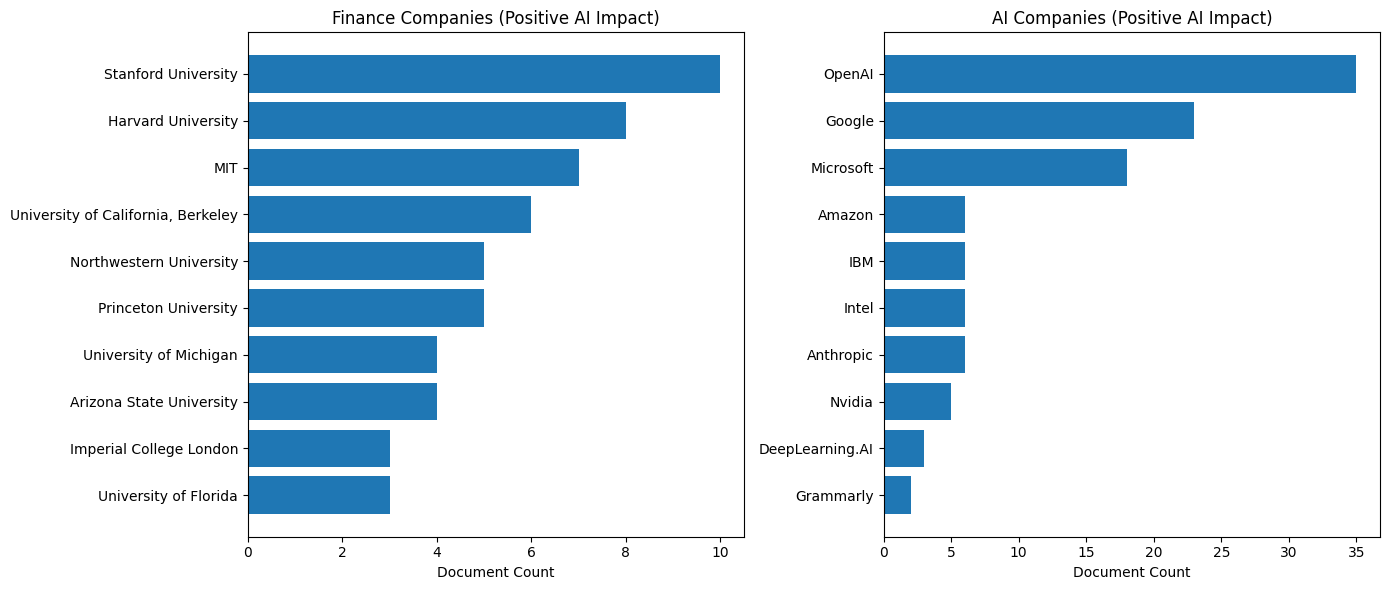

In [31]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_pos.sort_values("total_count")
ai_df = ai_company_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Finance Companies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [32]:
df_posmech_long = (
    df_ai_impact_ner_result_pos[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_posmech_long = df_posmech_long[df_posmech_long["ai_technologies_or_mechanisms"].notna()].copy()
df_posmech_long["entity_raw"] = (
    df_posmech_long["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_posmech_long = df_posmech_long[ df_posmech_long["entity_raw"] != ""]

posmech_raw_counts = (
    df_posmech_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(posmech_raw_counts.shape)

posmech_candidates = posmech_raw_counts.loc[
    posmech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(posmech_candidates.shape)

posmech_candidates

(1220, 2)
(191, 2)


,entity_raw,raw_count
0,machine learning,119
1,ChatGPT,97
2,AI,77
3,artificial intelligence,71
4,generative AI,67
...,...,...
186,AI skills,2
187,AI system,2
188,AI teaching tool,2
189,writing grant proposals,2


In [33]:
posmech_candidate_pairs = list(
    posmech_candidates[["entity_raw", "raw_count"]]
    .itertuples(index=False, name=None)
)
posmech_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in posmech_candidate_pairs])
posmech_candidate_pairs_str

'- (machine learning, 119)\n- (ChatGPT, 97)\n- (AI, 77)\n- (artificial intelligence, 71)\n- (generative AI, 67)\n- (personalized learning, 41)\n- (AI tools, 40)\n- (student cheating using AI, 39)\n- (AI tutoring, 34)\n- (AI-generated assignments, 32)\n- (automated grading, 21)\n- (natural language processing, 18)\n- (chatbots, 14)\n- (AI literacy, 14)\n- (neural networks, 13)\n- (AI chatbot, 13)\n- (academic integrity risks, 11)\n- (AI tool, 10)\n- (artificial intelligence (AI), 10)\n- (academic integrity, 10)\n- (deep learning, 10)\n- (AI education, 9)\n- (large language models, 9)\n- (academic writing assistance, 9)\n- (Artificial Intelligence (AI), 8)\n- (Artificial Intelligence, 8)\n- (cheating, 8)\n- (AI in education, 8)\n- (AI technology, 7)\n- (AI-generated text, 7)\n- (plagiarism detection, 6)\n- (AI-generated content, 6)\n- (scientific discovery acceleration, 6)\n- (plagiarism, 6)\n- (AI algorithms, 6)\n- (research automation, 6)\n- (AI applications, 6)\n- (computer vision, 6)

In [35]:
posmech_top_system_msg = """\
You are an AI technology and education & research impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts
extracted from education and research-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_education_research_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI education & research positive impact mechanisms


Definitions:


### core_ai_technology
Fundamental AI technologies, models, or technical approaches.

Examples:
- large language models
- generative AI
- machine learning
- deep learning
- neural networks
- predictive analytics
- computer vision
- natural language processing
- code generation models


### ai_education_research_mechanism
Applications, institutional capabilities, or workflow mechanisms through which AI
positively affects education systems, academic institutions, or scientific research.

Examples:

Education improvements
- personalized learning
- AI tutoring
- intelligent tutoring systems
- adaptive learning platforms
- automated grading
- student support assistants

Research productivity
- literature review automation
- research assistants
- scientific data analysis
- hypothesis generation
- knowledge discovery
- coding assistance for research

Academic workflow improvements
- academic writing assistance
- document summarization
- research workflow automation
- collaboration support
- data processing automation


### other
Anything vague, unclear, or not clearly technology or mechanism.


Rules:
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.
- machine learning, deep learning, and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""

mech_top_user_template = """\
Here is the list of (technology_or_mechanism_name, mention_count):

{candidate_list}

Return JSON in this exact format:

{{
  "core_ai_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ],
  "ai_mechanism_top10": [
    {{
      "canonical_name": "...",
      "total_count": 0,
      "source_raw_names": ["...", "..."]
    }}
  ]
}}
"""

mech_top_json_schema = {
    "type": "object",
    "properties": {
        "core_ai_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        },
        "ai_mechanism_top10": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "canonical_name": {"type": "string"},
                    "total_count": {"type": "number"},
                    "source_raw_names": {
                        "type": "array",
                        "items": {"type": "string"}
                    }
                },
                "required": ["canonical_name", "total_count", "source_raw_names"],
                "additionalProperties": False
            }
        }
    },
    "required": ["core_ai_top10", "ai_mechanism_top10"],
    "additionalProperties": False
}

In [36]:
user_msg = mech_top_user_template.format(candidate_list=posmech_candidate_pairs_str)
result_posmech = generate_text(
    client=client,
    system_msg=posmech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_posmech, schema=mech_top_json_schema)

In [37]:
technology_top10_pos = pd.DataFrame(result_posmech["core_ai_top10"])
mechanism_top10_pos = pd.DataFrame(result_posmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_pos)

print("AI Business Mechanism Top 10")
display(mechanism_top10_pos)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,machine learning,156,"[machine learning, neural networks, deep learn..."
1,large language models,119,"[ChatGPT, large language models, AI-powered la..."
2,generative AI,70,"[generative AI, AI-generated text, AI-generate..."
3,artificial intelligence,77,"[AI, artificial intelligence, artificial intel..."
4,natural language processing,18,[natural language processing]
5,computer vision,8,"[computer vision, image recognition, image ana..."
6,predictive analytics,6,"[predictive analytics, predictive modeling, pr..."
7,chatbots,39,"[chatbots, AI chatbot, chatbot, AI chatbots, c..."
8,code generation models,2,[code generation models]
9,robotics,4,[robotics]


AI Business Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,personalized learning,54,"[personalized learning, personalised learning,..."
1,AI tutoring,46,"[AI tutoring, AI tutors, AI tutor, AI Tutor, A..."
2,automated grading,23,"[automated grading, grading student work, auto..."
3,academic writing assistance,9,[academic writing assistance]
4,literature review automation,4,[literature review automation]
5,coding assistance for research,4,[coding assistance for research]
6,knowledge discovery,3,[knowledge discovery]
7,research automation,6,[research automation]
8,scientific discovery acceleration,6,[scientific discovery acceleration]
9,adaptive learning,2,[adaptive learning]


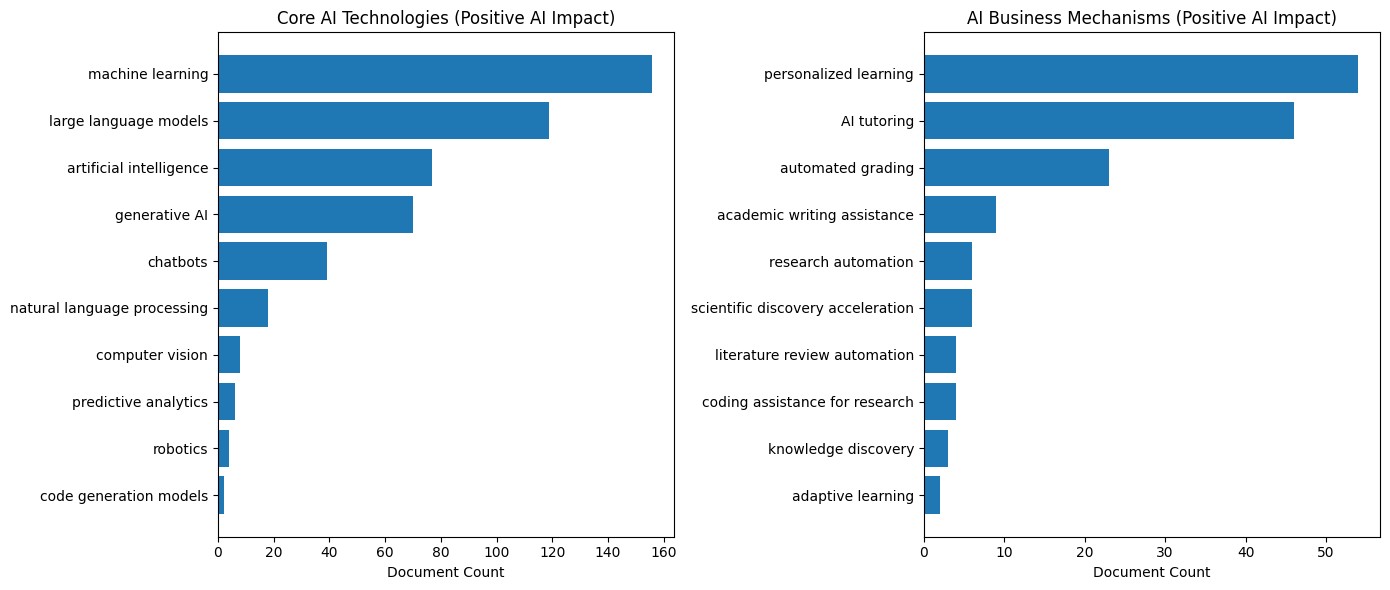

In [38]:
import matplotlib.pyplot as plt

tech_df = technology_top10_pos.sort_values("total_count")
mech_df = mechanism_top10_pos.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Positive AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Positive AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

#### Negative impact

In [17]:
df_ai_negative_impact_ner_sample = df_ai_impact_pred.loc[df_ai_impact_pred['pred_label'] == 'negatively'].sample(500, random_state=42).reset_index(drop=True)
print(len(df_ai_negative_impact_ner_sample))

500


In [18]:
neg_entity_system_msg = """\
You are an information extraction system for education and research-related news articles.

The user will provide a text block from a news article related to education,
academia, or scientific research.
This dataset is focused on negative AI impact.

Your task is to extract only the following:

1. organizations or institutions in the education and research ecosystem explicitly mentioned in the text
2. AI-related technologies, capabilities, or NEGATIVE impact mechanisms explicitly mentioned in the text


## ORGANIZATIONS

Extract named organizations or institutions explicitly stated in the text.

These may include:
- universities and colleges
- K–12 school systems
- research institutes and laboratories
- academic publishers
- scholarly organizations
- educational technology companies
- academic funding bodies
- scientific collaborations
- policy institutions related to education or research

Examples:
- Harvard University
- Stanford University
- MIT
- Oxford University
- Cambridge University
- OpenAI
- Google DeepMind
- Elsevier
- Springer Nature
- arXiv
- National Science Foundation
- National Institutes of Health


## AI_TECHNOLOGIES_OR_MECHANISMS

Extract:
- AI-related technologies or capabilities explicitly mentioned in the text
- AI-related negative educational or research impact mechanisms explicitly mentioned in the text

Examples of technologies / capabilities:
- generative AI
- large language models
- machine learning
- predictive analytics
- computer vision
- natural language processing
- AI tutors
- AI research assistants
- code generation models


Examples of NEGATIVE impact mechanisms:

Academic integrity risks
- AI-assisted cheating
- AI-written assignments
- plagiarism using AI
- academic integrity violations

Research reliability risks
- hallucinated citations
- fabricated references
- unreliable AI-generated research
- incorrect scientific conclusions

Educational disruption
- decline in student learning outcomes
- overreliance on AI tools
- reduced critical thinking
- misuse of AI in coursework

Institutional risks
- erosion of academic standards
- policy challenges in universities
- unreliable automated grading
- ethical concerns in research


## Directions

- Focus especially on negative AI-related mechanisms, risks, harms, and downsides in education and research.
- Only extract information explicitly supported by the text.
- Do not infer entities that are not directly mentioned.
- Remove duplicates.
- Keep entity names concise and canonical when possible.
- Do not extract generic references such as “the university”, “the researchers”, “the institution”, or “the students”
  unless a specific named entity is given.
- Do not treat individual professors, researchers, scientists, or students as organizations.
- If none are present, return an empty list.
- Return valid JSON only.
"""

In [19]:
train_ai_negative_impact_ner = []

for idx, row in df_ai_negative_impact_ner_sample.iterrows():

    title = "" if pd.isna(row["title"]) else str(row["title"])
    text = "" if pd.isna(row["text"]) else str(row["text"])

    user_msg = entity_user_template.format(
        title=title[:500],
        text=text[:12000]
    )

    try:
        raw_result = generate_text(
            client=client,
            system_msg=neg_entity_system_msg,
            user_msg=user_msg,
            model="deepseek-chat"
        )

        result = normalize_entity_result(raw_result)
        result["api_status"] = "success"

    except Exception as e:
        err_msg = str(e)
        result = {
            "organizations": None,
            "ai_technologies_or_mechanisms": None,
            "api_status": f"failed: {err_msg}"
        }
        print(f"[Row {idx}] Failed: {e}")

    result["chunk_uid"] = row["chunk_uid"]
    result["title"] = title
    result["text"] = text
    result["pred_label"] = row["pred_label"]
    result["topic"] = row["topic"]

    train_ai_negative_impact_ner.append(result)
    
df_ai_negative_impact_ner_result = pd.DataFrame(train_ai_negative_impact_ner)

In [20]:
df_ai_negative_impact_ner_result.to_parquet(f"{DATA_DIR}/EDU_specific/edu_ai_negative_impact_ner.parquet", index=False)

##### Organization 

In [39]:
df_negorg_long = (
    df_ai_negative_impact_ner_result[["chunk_uid", "organizations"]]
    .explode("organizations")
)

df_negorg_long = df_negorg_long[df_negorg_long["organizations"].notna()].copy()
df_negorg_long["entity_raw"] = df_negorg_long["organizations"].astype(str).str.strip()
df_negorg_long = df_negorg_long[df_negorg_long["entity_raw"] != ""]

negorg_raw_counts = (
    df_negorg_long.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)
print(negorg_raw_counts.shape)
negorg_candidates = negorg_raw_counts.loc[negorg_raw_counts["raw_count"] >= 2, ["entity_raw",'raw_count']].copy()
print(negorg_candidates.shape)
negorg_candidates

(641, 2)
(172, 2)


,entity_raw,raw_count
0,OpenAI,116
1,Microsoft,23
2,Turnitin,19
3,Furman University,14
4,Seattle Public Schools,13
...,...,...
167,Hingham High School,2
168,Heinz College of Information Systems and Publi...,2
169,Walla Walla Public Schools,2
170,Georgia Tech,2


In [40]:
negorg_candidate_pairs = list(negorg_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
negorg_candidate_pairs_str = "\n".join( [f"- ({name}, {count})" for name, count in negorg_candidate_pairs])
negorg_candidate_pairs_str

"- (OpenAI, 116)\n- (Microsoft, 23)\n- (Turnitin, 19)\n- (Furman University, 14)\n- (Seattle Public Schools, 13)\n- (Google, 13)\n- (Temple University, 12)\n- (Conestoga College, 12)\n- (New York City Public Schools, 10)\n- (Princeton University, 9)\n- (CNN, 9)\n- (Harvard, 8)\n- (Los Angeles Unified School District, 8)\n- (Texas A&M, 8)\n- (NPR, 8)\n- (New York City education department, 8)\n- (The Associated Press, 6)\n- (University of Pennsylvania, 6)\n- (Business Insider, 6)\n- (The Atlantic, 6)\n- (Wharton School, 6)\n- (MIT, 6)\n- (New York City school officials, 6)\n- (AI Education Project, 5)\n- (Michigan State University, 5)\n- (Sciences Po, 5)\n- (New York City, 5)\n- (Arizona State University, 5)\n- (University of California, Berkeley, 5)\n- (University of Calgary, 5)\n- (Texas A&M University-Commerce, 4)\n- (Carnegie Mellon University, 4)\n- (Cambridge, 4)\n- (Stanford, 4)\n- (Oxford, 4)\n- (Open AI, 4)\n- (The Washington Post, 4)\n- (CNET, 4)\n- (Brigham Young University, 

In [41]:
user_msg = org_top_user_template.format(candidate_list=negorg_candidate_pairs_str)

result_negorg = generate_text(
    client=client,
    system_msg=org_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negorg, schema=org_top_json_schema)

In [43]:
industry_company_top10_neg = pd.DataFrame(result_negorg["education_research_top10"])
ai_company_top10_neg = pd.DataFrame(result_negorg["ai_top10"])

print("Education and Research Top 10")
display(industry_company_top10_neg)

print("AI Top 10")
display(ai_company_top10_neg)

Education and Research Top 10


,canonical_name,total_count,source_raw_names
0,New York City Public Schools,38,"[New York City Public Schools, New York City e..."
1,Seattle Public Schools,16,"[Seattle Public Schools, Seattle public schools]"
2,Los Angeles Unified School District,14,"[Los Angeles Unified School District, Los Ange..."
3,Texas A&M University,12,"[Texas A&M, Texas A&M University-Commerce]"
4,University of Pennsylvania,8,"[University of Pennsylvania, Wharton School, W..."
5,Princeton University,12,"[Princeton University, Princeton]"
6,Temple University,15,"[Temple University, Temple]"
7,Stanford University,7,"[Stanford, Stanford University]"
8,MIT,6,[MIT]
9,Harvard University,8,[Harvard]


AI Top 10


,canonical_name,total_count,source_raw_names
0,OpenAI,120,"[OpenAI, Open AI]"
1,Microsoft,23,[Microsoft]
2,Google,13,[Google]
3,Turnitin,19,[Turnitin]
4,GPTZero,4,[GPTZero]
5,Hugging Face,3,[Hugging Face]
6,Anthropic,2,[Anthropic]
7,Midjourney,2,[Midjourney]
8,Baidu,3,[Baidu]
9,Alibaba,2,[Alibaba]


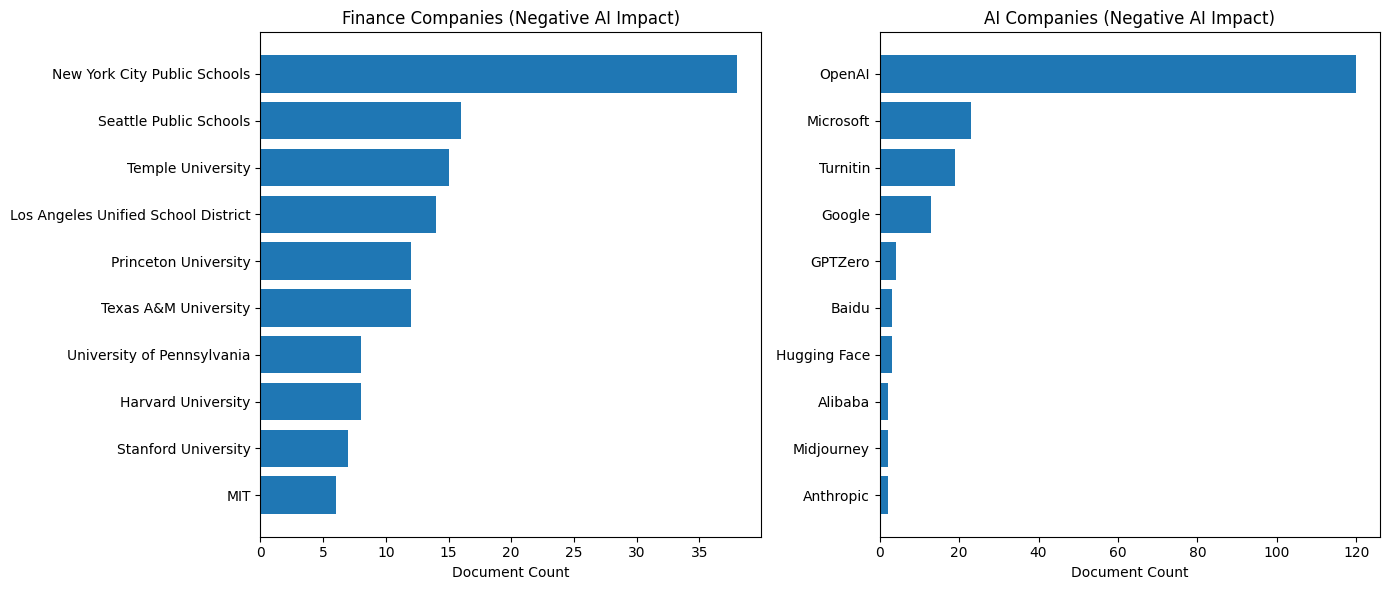

In [44]:
import matplotlib.pyplot as plt
import numpy as np

finance_df = industry_company_top10_neg.sort_values("total_count")
ai_df = ai_company_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# ---  Finance ---
axes[0].barh(finance_df["canonical_name"], finance_df["total_count"])
axes[0].set_title("Finance Companies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# ---  AI ---
axes[1].barh(ai_df["canonical_name"], ai_df["total_count"])
axes[1].set_title("AI Companies (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

##### Technology and Mechanism 

In [45]:
df_ai_mech_long_neg = (
    df_ai_negative_impact_ner_result[["chunk_uid", "ai_technologies_or_mechanisms"]]
    .explode("ai_technologies_or_mechanisms")
)
df_ai_mech_long_neg = df_ai_mech_long_neg[df_ai_mech_long_neg["ai_technologies_or_mechanisms"].notna()].copy()
df_ai_mech_long_neg["entity_raw"] = (
    df_ai_mech_long_neg["ai_technologies_or_mechanisms"]
    .astype(str)
    .str.strip()
)
df_ai_mech_long_neg = df_ai_mech_long_neg[ df_ai_mech_long_neg["entity_raw"] != ""]

neg_ai_mech_raw_counts = (
    df_ai_mech_long_neg.groupby("entity_raw", as_index=False)
    .agg(raw_count=("chunk_uid", "size"))
    .sort_values("raw_count", ascending=False)
    .reset_index(drop=True)
)

print(neg_ai_mech_raw_counts.shape)

neg_ai_mech_candidates = neg_ai_mech_raw_counts.loc[
    neg_ai_mech_raw_counts["raw_count"] >= 2,
    ["entity_raw", "raw_count"]
].copy()

print(neg_ai_mech_candidates.shape)

neg_ai_mech_candidates

(883, 2)
(190, 2)


,entity_raw,raw_count
0,ChatGPT,371
1,AI-assisted cheating,295
2,academic integrity violations,164
3,misuse of AI in coursework,142
4,overreliance on AI tools,112
...,...,...
185,unreliable results,2
186,AI algorithms,2
187,unreliable AI-generated content,2
188,unreliable AI detection,2


In [46]:
neg_candidate_pairs = list( neg_ai_mech_candidates[["entity_raw", "raw_count"]].itertuples(index=False, name=None))
neg_candidate_pairs_str = "\n".join([f"- ({name}, {count})" for name, count in neg_candidate_pairs])
neg_candidate_pairs_str

'- (ChatGPT, 371)\n- (AI-assisted cheating, 295)\n- (academic integrity violations, 164)\n- (misuse of AI in coursework, 142)\n- (overreliance on AI tools, 112)\n- (policy challenges in universities, 95)\n- (reduced critical thinking, 87)\n- (decline in student learning outcomes, 84)\n- (erosion of academic standards, 80)\n- (plagiarism using AI, 77)\n- (AI-written assignments, 68)\n- (ethical concerns in research, 50)\n- (generative AI, 50)\n- (AI tools, 46)\n- (AI, 45)\n- (artificial intelligence, 44)\n- (unreliable AI-generated research, 42)\n- (AI-generated text, 25)\n- (cheating, 25)\n- (large language models, 21)\n- (unreliable automated grading, 18)\n- (hallucinated citations, 18)\n- (incorrect scientific conclusions, 18)\n- (GPT-3, 17)\n- (chatbots, 14)\n- (AI chatbots, 14)\n- (AI chatbot, 13)\n- (fabricated references, 12)\n- (AI-written text, 12)\n- (plagiarism, 12)\n- (AI detectors, 11)\n- (AI-generated content, 11)\n- (AI-generated chatbots, 10)\n- (AI tool, 10)\n- (artific

In [47]:
neg_mech_top_system_msg = """\
You are an AI technology and education & research impact mechanism consolidation system.

The user will provide a list of AI-related technologies or mechanisms with mention counts
extracted from education and research-related AI news.

Your tasks:

1. Merge raw names that clearly refer to the same concept into one canonical_name.
2. Classify canonical concepts into:
   - core_ai_technology
   - ai_education_research_mechanism
   - other
3. Sum counts of merged raw names.
4. Rank by total_count.
5. Return:
   - Top 10 core AI technologies
   - Top 10 AI education & research negative impact mechanisms


Definitions


### core_ai_technology
Fundamental AI technologies, models, or technical approaches.

Examples:
- large language models
- generative AI
- machine learning
- deep learning
- neural networks
- predictive analytics
- computer vision
- natural language processing
- code generation models


### ai_education_research_mechanism
Mechanisms through which AI negatively affects education systems,
academic institutions, or scientific research.

Examples of NEGATIVE impact mechanisms:

Academic integrity risks
- AI-assisted cheating
- AI-written assignments
- plagiarism using AI
- academic integrity violations

Research reliability risks
- hallucinated citations
- fabricated references
- unreliable AI-generated research
- incorrect scientific conclusions
- fake academic papers

Educational disruption
- decline in student learning outcomes
- overreliance on AI tools
- reduced critical thinking
- misuse of AI in coursework

Institutional risks
- erosion of academic standards
- challenges for university policies
- unreliable automated grading
- ethical concerns in research
- academic misconduct enabled by AI


### other
Anything vague, unclear, or not clearly technology or mechanism.


Rules
- Merge only when clearly referring to the same concept.
- Be conservative.
- Keep canonical names concise.
- Use counts exactly as provided.
- Only classify items as ai_education_research_mechanism when the education,
  academic, or research context is clear.
- machine learning, deep learning and neural networks should be grouped under machine learning.
- ChatGPT should be grouped under large language models.

Return valid JSON only.
"""

In [48]:
user_msg = mech_top_user_template.format(candidate_list=neg_candidate_pairs_str)
result_negmech = generate_text(
    client=client,
    system_msg=neg_mech_top_system_msg,
    user_msg=user_msg,
    model="deepseek-chat"
)

validate(instance=result_negmech, schema=mech_top_json_schema)

In [49]:
technology_top10_neg = pd.DataFrame(result_negmech["core_ai_top10"])
ai_mechanism_top10_neg = pd.DataFrame(result_negmech["ai_mechanism_top10"])

print("Core AI Technology Top 10")
display(technology_top10_neg)

print("AI Business Negative Impact Mechanism Top 10")
display(ai_mechanism_top10_neg)

Core AI Technology Top 10


,canonical_name,total_count,source_raw_names
0,large language models,447,"[ChatGPT, large language models, GPT-3, chatbo..."
1,generative AI,63,"[generative AI, generative AI tools, generativ..."
2,machine learning,12,"[machine learning, deep learning]"
3,AI detection tools,35,"[AI detectors, AI detection tool, AI detection..."
4,natural language processing,2,[natural language processing]
5,AI writing tools,5,[AI writing tools]
6,AI-powered translation tool,3,[AI-powered translation tool]
7,BERT,3,[BERT]
8,transformer technique,3,[transformer technique]
9,AI-enabled facial recognition systems,2,[AI-enabled facial recognition systems]


AI Business Negative Impact Mechanism Top 10


,canonical_name,total_count,source_raw_names
0,AI-assisted cheating,331,"[AI-assisted cheating, cheating, AI cheating, ..."
1,academic integrity violations,176,"[academic integrity violations, plagiarism usi..."
2,misuse of AI in coursework,142,[misuse of AI in coursework]
3,overreliance on AI tools,112,[overreliance on AI tools]
4,reduced critical thinking,96,"[reduced critical thinking, lack of critical t..."
5,decline in student learning outcomes,94,"[decline in student learning outcomes, negativ..."
6,erosion of academic standards,80,[erosion of academic standards]
7,AI-written assignments,80,"[AI-written assignments, AI-written text, AI-w..."
8,unreliable AI-generated research,75,"[unreliable AI-generated research, hallucinate..."
9,ethical concerns in research,50,[ethical concerns in research]


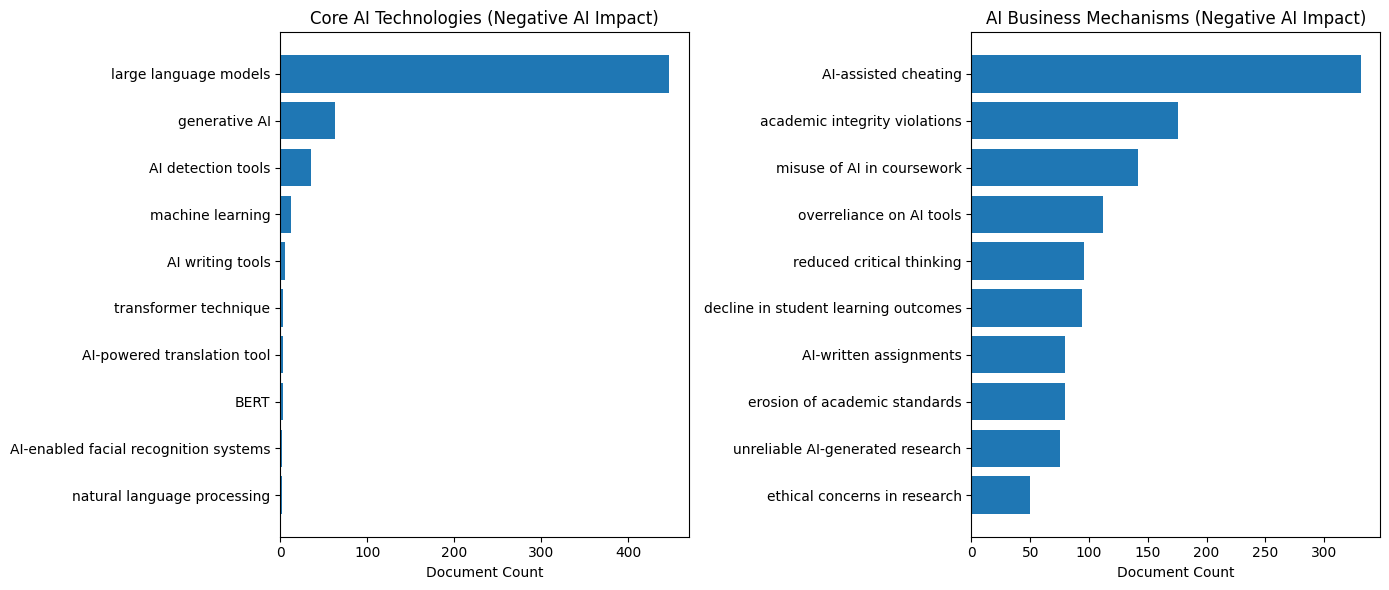

In [50]:
import matplotlib.pyplot as plt

tech_df = technology_top10_neg.sort_values("total_count")
mech_df = ai_mechanism_top10_neg.sort_values("total_count")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Core AI Technology ---
axes[0].barh(tech_df["canonical_name"], tech_df["total_count"])
axes[0].set_title("Core AI Technologies (Negative AI Impact)")
axes[0].set_xlabel("Document Count")

# --- AI Business Mechanism ---
axes[1].barh(mech_df["canonical_name"], mech_df["total_count"])
axes[1].set_title("AI Business Mechanisms (Negative AI Impact)")
axes[1].set_xlabel("Document Count")

plt.tight_layout()
plt.show()

### Aggregated Sentiment Anaysis

In [51]:
df_ai_impact_pred = pd.read_parquet(f"{DATA_DIR}/edu_models/edu_senti_predictions.parquet")

#### Topic Aggregation

In [52]:
Industry_topics = pd.read_csv(f"{DATA_DIR}/EDU_specific/Industry_topics.csv")
Industry_chunks_topics = pd.read_parquet(f"{DATA_DIR}/EDU_specific/Industry_chunks_topics.parquet")

In [53]:
ai_impact_topic_id = [0,1,2,3]
ai_impact_topics = Industry_topics[Industry_topics["Topic"].isin(ai_impact_topic_id)][['Topic','Representation','Representative_Docs']].copy()
ai_impact_topics

,Topic,Representation,Representative_Docs
1,0,"['teachers', 'educators', 'writing', 'teaching...","['(Turnitin already works with 16,000 schools,..."
2,1,"['scientist', 'data scientist', 'engineer', 'c...","[""Your electronic Certificate will be added to..."
3,2,"['mars', 'sciencedaily', 'stars', 'chemical', ...","[""Please select the most appropriate category ..."
4,3,"['suicide', 'google scholar', 'attributions', ...",['SafetyLit: Identifying suicide attempter in ...


In [54]:
topic_summary_system_msg = """\
You are a topic interpretation system.

The user will provide:
- topic keywords
- representative documents

Your task:
Summarize what this topic is mainly about in one concise sentence (max 20 words).

Return plain text only.
"""
topic_summary_user_template = """\
Topic keywords:
{keywords}

Representative documents:
{docs}

What is this topic mainly about?
"""
def generate_text_plain(client, system_msg, user_msg, model="deepseek-chat"):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ],
        temperature=0
    )
    return response.choices[0].message.content.strip()
summaries = []

for _, row in ai_impact_topics.iterrows():
    
    keywords = row["Representation"]
    docs = row["Representative_Docs"]
    
    user_msg = topic_summary_user_template.format(
        keywords=str(keywords),
        docs=str(docs)[:4000]   # 防止太长
    )
    
    summary = generate_text_plain(
        client=client,
        system_msg=topic_summary_system_msg,
        user_msg=user_msg
    )
    
    summaries.append(summary)

ai_impact_topics["topic_summary"] = summaries
show_full(ai_impact_topics[["Topic", "topic_summary"]])

,Topic,topic_summary
1,0,Educators are adapting teaching methods to address student cheating with AI tools like ChatGPT.
2,1,This topic is about online professional certifications for data science and cloud engineering careers.
3,2,"This topic covers astronomy and space science news, including discoveries about Mars, stars, and galaxies."
4,3,This topic is about using machine learning to predict suicide risk from psychological and neural data.


In [55]:
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["chunk_uid"].astype(str).str.split("_").str[0]
df_ai_impact_pred["doc_id"] = df_ai_impact_pred["doc_id"].astype(int)

display(df_ai_impact_pred.head(2))

,chunk_uid,url,date,title,topic,text,pred_label,max_prob,prob_negatively,prob_hard-to-say,prob_positively,doc_id
0,88_0_0_0_0,https://www.edexlive.com/news/2024/Oct/23/in-a...,2024-10-23,"""In a future where AI is more prevalent, teach...",0,"""In a future where AI is more prevalent, teach...",positively,0.926871,0.019520,0.053609,0.926871,88
1,166_0_0_0_0,https://celebritiesdeaths.com/switching-to-dat...,2023-05-25,"""Switching To Data Science Career"": ""Guide On ...",1,"""Switching To Data Science Career"": ""Guide On ...",hard-to-say,0.929538,0.025211,0.929538,0.045251,166


In [56]:
# Group by topic and pred_label, and count the nunique of doc_id in each group
aiimpact_topic_label_doc_counts = (
    df_ai_impact_pred
    .groupby(["topic", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_counts")
    .reset_index()
    .pivot(index="topic", columns="pred_label", values="doc_counts")
    .fillna(0)
    .reset_index()
)
display(aiimpact_topic_label_doc_counts)


# percentage calculation
aiimpact_topic_label_doc_prop = (
    aiimpact_topic_label_doc_counts
    .set_index("topic")
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0))
    .reset_index()
)

aiimpact_topic_label_doc_prop_pct = aiimpact_topic_label_doc_prop.copy()
cols = aiimpact_topic_label_doc_prop_pct.columns.drop("topic")
aiimpact_topic_label_doc_prop_pct[cols] = (
    aiimpact_topic_label_doc_prop_pct[cols]
    .mul(100)
    .round(2)
    .astype(str)
    .add("%")
)
aiimpact_topic_label_doc_prop_pct

pred_label,topic,hard-to-say,negatively,positively
0,0,1193,983,1561
1,1,626,1,241
2,2,158,3,350
3,3,50,1,232


pred_label,topic,hard-to-say,negatively,positively
0,0,31.92%,26.3%,41.77%
1,1,72.12%,0.12%,27.76%
2,2,30.92%,0.59%,68.49%
3,3,17.67%,0.35%,81.98%


In [57]:
# Topic-level impact polarity score
aiimpact_topic_label_doc_prop["impact_score"] = (
    aiimpact_topic_label_doc_prop["positively"]
    - aiimpact_topic_label_doc_prop["negatively"]
)

display(aiimpact_topic_label_doc_prop)

pred_label,topic,hard-to-say,negatively,positively,impact_score
0,0,0.319240,0.263045,0.417715,0.154670
1,1,0.721198,0.001152,0.277650,0.276498
2,2,0.309198,0.005871,0.684932,0.679061
3,3,0.176678,0.003534,0.819788,0.816254


The correction assumes that the observed predicted label distribution is a noisy transformation of the true label distribution.

The confusion matrix describes how true labels are converted into predicted labels.

By inverting this transformation, we estimate the underlying true distribution of labels at the topic level.

In [58]:
labels = ["negatively", "hard-to-say", "positively"]

C = np.array([
    [0.70, 0.20, 0.10],
    [0.13, 0.66, 0.21],
    [0.00, 0.16, 0.84]
])

C_inv = np.linalg.inv(C.T)

def correct_distribution(row):
    pred_dist = row[labels].values.astype(float)
    corrected = C_inv @ pred_dist
    corrected = np.clip(corrected, 0, 1)
    corrected = corrected / corrected.sum()
    return corrected

corrected_values = np.vstack(aiimpact_topic_label_doc_prop.apply(correct_distribution, axis=1))

aiimpact_topic_label_doc_prop_corrected = aiimpact_topic_label_doc_prop.copy().drop(columns='impact_score')
aiimpact_topic_label_doc_prop_corrected[labels] = corrected_values

aiimpact_topic_label_doc_prop_corrected["impact_score_corrected"] = (
    aiimpact_topic_label_doc_prop_corrected["positively"]
    - aiimpact_topic_label_doc_prop_corrected["negatively"]
)
display(aiimpact_topic_label_doc_prop_corrected)

pred_label,topic,hard-to-say,negatively,positively,impact_score_corrected
0,0,0.292767,0.321408,0.385825,0.064417
1,1,0.933944,0.000000,0.066056,0.066056
2,2,0.288444,0.000000,0.711556,0.711556
3,3,0.033411,0.000000,0.966589,0.966589


#### Time Aggregation

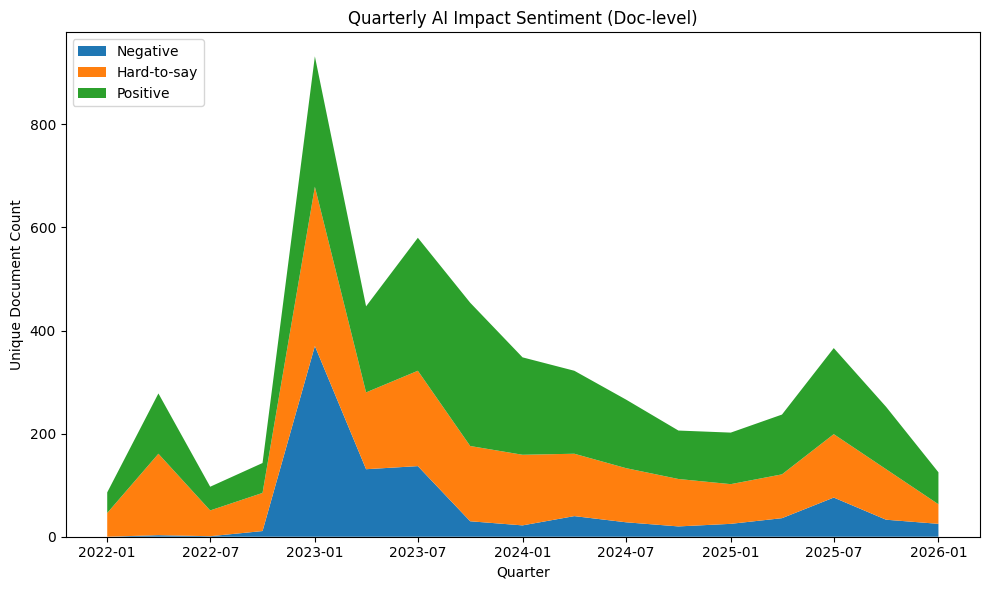

In [59]:
df_ai_impact_pred["date"] = pd.to_datetime(df_ai_impact_pred["date"])
df_ai_impact_pred["quarter"] = df_ai_impact_pred["date"].dt.to_period("Q")
quarter_sent_doc = (
    df_ai_impact_pred
    .groupby(["quarter", "pred_label"])["doc_id"]
    .nunique()
    .rename("doc_count")
    .reset_index()
)
quarter_sent_pivot = (
    quarter_sent_doc
    .pivot(index="quarter", columns="pred_label", values="doc_count")
    .fillna(0)
    .sort_index()
)

import matplotlib.pyplot as plt

quarter_sent_pivot.index = quarter_sent_pivot.index.to_timestamp()

plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_pivot.index,
    quarter_sent_pivot.get("negatively", 0),
    quarter_sent_pivot.get("hard-to-say", 0),
    quarter_sent_pivot.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level)")
plt.xlabel("Quarter")
plt.ylabel("Unique Document Count")
plt.tight_layout()
plt.show()

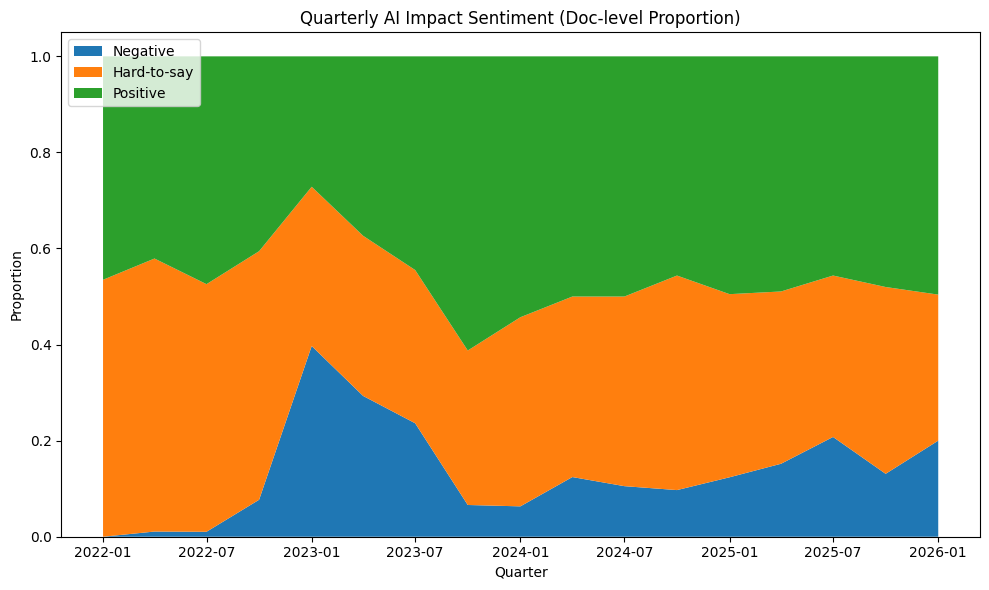

In [60]:
quarter_sent_prop = (
    quarter_sent_pivot
    .div(quarter_sent_pivot.sum(axis=1), axis=0)
)
plt.figure(figsize=(10,6))

plt.stackplot(
    quarter_sent_prop.index,
    quarter_sent_prop.get("negatively", 0),
    quarter_sent_prop.get("hard-to-say", 0),
    quarter_sent_prop.get("positively", 0),
    labels=["Negative", "Hard-to-say", "Positive"]
)

plt.legend(loc="upper left")
plt.title("Quarterly AI Impact Sentiment (Doc-level Proportion)")
plt.xlabel("Quarter")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()